# Task 2: Bayesian Change Point Modeling and Insight Generation

## Brent Crude Oil Price Structural Break Analysis

### Objective

The objective of this task is to apply Bayesian Change Point Detection to identify structural breaks in Brent crude oil prices and quantify their impact.

The analysis investigates whether historical oil price behavior changed significantly due to major geopolitical, economic, or market events.

The workflow includes:

- Data preparation
- Exploratory time series analysis
- Log return analysis
- Bayesian Change Point Modeling using PyMC
- MCMC sampling
- Posterior inference
- Structural break identification
- Historical event comparison
- Economic interpretation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import arviz as az


import sys
sys.path.append("../")


print("Libraries loaded")

Libraries loaded


In [2]:
from src.data_loader import (
    load_brent_data,
    convert_date_column
)


from src.preprocessing import (
    create_price_features,
    prepare_model_data
)


from src.eda import (
    dataset_overview,
    summary_statistics
)


from src.visualization import (
    plot_price_history,
    plot_change_point,
    plot_Log_Return_Analysis,
    plot_rolling_volatility    
)


from src.bayesian_model import (
    build_change_point_model,
    run_sampler
)


from src.change_point import (
    extract_change_point,
    quantify_impact
)


from src.event_analysis import (
    find_nearest_event
)


print("Project modules loaded")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Project modules loaded


In [3]:
DATA_PATH="../data/brent_processed.csv"


df = load_brent_data(
    DATA_PATH
)


df = convert_date_column(
    df
)


df.head()

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Volatility
0,1987-05-20,18.63,2.924773,NaN,NaN,NaN
1,1987-05-21,18.45,2.915064,-0.18,-0.009709,NaN
2,1987-05-22,18.55,2.920470,0.10,0.005405,NaN
3,1987-05-25,18.60,2.923162,0.05,0.002692,NaN
4,1987-05-26,18.63,2.924773,0.03,0.001612,NaN


In [4]:
dataset_overview(df)

{'rows': 9011,
 'columns': 6,
 'column_names': ['Date',
  'Price',
  'Log_Price',
  'Price_Change',
  'Log_Return',
  'Rolling_Volatility'],
 'missing_values': {'Date': 0,
  'Price': 0,
  'Log_Price': 0,
  'Price_Change': 1,
  'Log_Return': 1,
  'Rolling_Volatility': 30},
 'duplicates': np.int64(0)}

In [5]:
summary_statistics(df)

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Volatility
count,9011,9011.000000,9011.000000,9010.000000,9010.000000,8981.000000
mean,2005-02-10 23:46:53.760958,48.420782,3.638729,0.008320,0.000179,0.021564
min,1987-05-20 00:00:00,9.100000,2.208274,-16.600000,-0.643699,0.005807
25%,1996-03-20 12:00:00,19.050000,2.947067,-0.390000,-0.011154,0.014916
50%,2005-02-02 00:00:00,38.570000,3.652475,0.020000,0.000402,0.019305
75%,2014-01-09 12:00:00,70.090000,4.249780,0.450000,0.012127,0.024429
max,2022-11-14 00:00:00,143.950000,4.969466,10.450000,0.412023,0.187314
std,NaN,32.860110,0.707122,1.216227,0.025532,0.013661


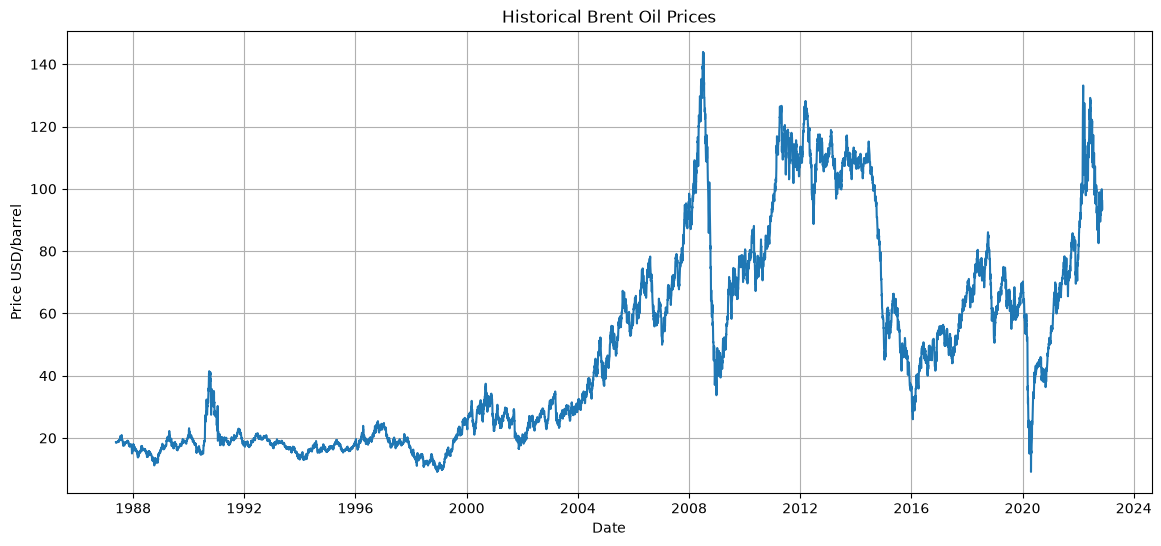

In [6]:
plot_price_history(df)

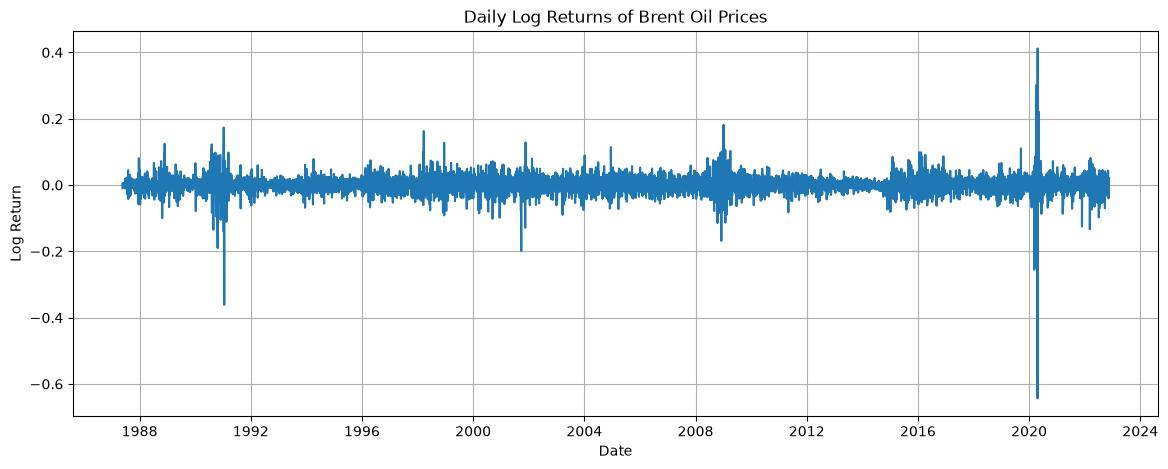

In [7]:
plot_Log_Return_Analysis(df)

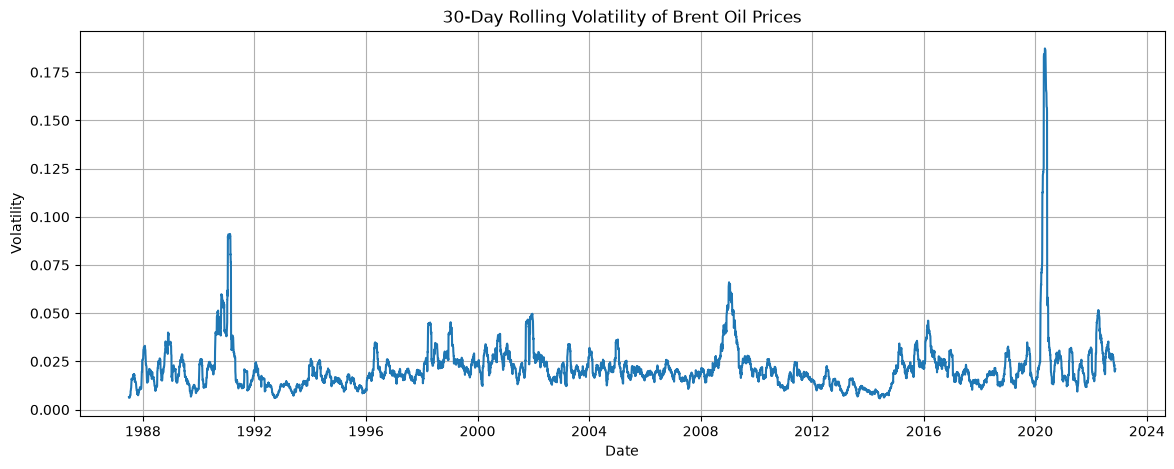

In [8]:
plot_rolling_volatility(df)

In [ ]:
#log_returns = prepare_model_data(
    #df,
   # "Price"
#)


#len(prices)

9011

In [ ]:
# Remove the first NaN created by differencing
log_returns = df["Log_Return"].dropna().values

print(log_returns[:10])
print(f"Number of observations: {len(log_returns)}")

In [10]:
model = build_change_point_model(
    prices
)


model

  tau ~ DiscreteUniform(f(), f())
  mu1 ~ Normal(48.4, 65.7)
  mu2 ~ Normal(48.4, 65.7)
sigma ~ HalfNormal(0, 32.9)
price ~ Normal(f(mu1, mu2, tau), sigma)

In [ ]:
trace = run_sampler(
    model,
    draws=1000,
    tune=1000
)

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

In [ ]:
summary = az.summary(
    trace
)


summary

In [ ]:
summary[
    [
        "mean",
        "sd",
        "ess_bulk",
        "r_hat"
    ]
]

In [ ]:
if (summary["r_hat"] < 1.01).all():

    print(
        "Model converged successfully"
    )

else:

    print(
        "Check convergence"
    )

In [ ]:
az.plot_trace(
    trace
)

plt.tight_layout()

plt.show()

In [ ]:
az.plot_posterior(
    trace
)

plt.show()

In [ ]:
tau = extract_change_point(
    trace
)


print(
    "Change point index:",
    tau
)

In [ ]:
change_date = df.iloc[tau]["Date"]


print(
    "Estimated change point date:",
    change_date
)

In [ ]:
tau_samples = (
    trace
    .posterior["tau"]
    .values
    .flatten()
)


plt.figure(figsize=(10,5))


plt.hist(
    tau_samples,
    bins=50
)


plt.axvline(
    tau,
    linestyle="--"
)


plt.title(
    "Posterior Distribution of Change Point"
)


plt.xlabel(
    "Time Index"
)


plt.ylabel(
    "Frequency"
)


plt.show()

In [ ]:
plot_change_point(
    df,
    change_date
)

In [ ]:
impact = quantify_impact(
    df,
    tau
)


impact

In [ ]:
before = impact["before_mean"]

after = impact["after_mean"]

change = impact["percentage_change"]


print(
f"""
The Bayesian model detected a structural break around {change_date.date()}.

Before the change point:
Average Brent price = ${before:.2f}

After the change point:
Average Brent price = ${after:.2f}

Estimated impact:
{change:.2f}% change in average price.
"""
)

In [ ]:
events = pd.read_excel(
    "../data/events.xlsx",
    parse_dates=["Date"]
)


events

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
nearest = find_nearest_event(
    events,
    change_date
)


nearest